# Machine Learning - Practical 1 - Linear Regression

Names: {NAME1, NAME2, Jakob_Kauws}  
Summer Term 2026  

This notebook provides you with the assignments and the overall code structure you need to complete the assignment. There are also questions that you need to answer in text form. Please use full sentences and reasonably correct spelling/grammar.

Regarding submission & grading:

- Work in groups of three and hand in your solution as a group.

- Solutions need to be uploaded to StudIP until the submission date indicated in the course plan. Please upload a copy of this notebook and a PDF version of it after you ran it.

- Solutions need to be presented to tutors in tutorial. Presentation dates are listed in the course plan. Every group member needs to be able to explain everything.

- You have to solve N-1 practicals to get admission to the exam.

- For plots you create yourself, all axes must be labeled. 

- Do not change the function interfaces.

## Imports

Jupyter Notebook provides the possibility of using libraries, functions and variables globally. This means, once you import the libraries, functions, etc. you won't have to import them again in the next cell. However, if for any reason you end the session (crash, timeout, etc.), then you'll have to run this cell to have your libraries imported again. So, let's go ahead and import whatever we need in this homework assignment.

In [1]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

## The  dataset

The dataset consists of over 20.000 materials and lists their physical features. From these features, we want to learn how to predict the critical temperature, i.e. the temperature we need to cool the material to so it becomes superconductive. First load and familiarize yourself with the data set a bit.

In [2]:
data = pd.read_csv("../data/superconduct_train.csv")
print(data.shape)

(21263, 82)


In [3]:
data.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


Because the dataset is rather large, we prepare a small subset of the data as training set, and another subset as test set. To make the computations reproducible, we set the random seed. This makes the train and test splits same even if you re-run the notebook. Keeping the splits same is important for the fair models comparison.

In [4]:
target_clm = 'critical_temp'  # the critical temperature is our target variable
n_trainset = 200  # size of the training set
n_testset = 500  # size of the test set

In [5]:
# set random seed to make sure every test set is the same
np.random.seed(seed=1)

idx = np.arange(data.shape[0])
idx_shuffled = np.random.permutation(idx)  # shuffle indices to split into training and test set

test_idx = idx_shuffled[:n_testset]
train_idx = idx_shuffled[n_testset:n_testset+n_trainset]
train_full_idx = idx_shuffled[n_testset:]

X_test_raw = data.loc[test_idx, data.columns != target_clm].values
y_test = data.loc[test_idx, data.columns == target_clm].values
print('Test set shapes (X and y)', X_test_raw.shape, y_test.shape)

X_train_raw = data.loc[train_idx, data.columns != target_clm].values
y_train = data.loc[train_idx, data.columns == target_clm].values
print('Small training set shapes (X and y):', X_train_raw.shape, y_train.shape)

X_train_full_raw = data.loc[train_full_idx, data.columns != target_clm].values
y_train_full = data.loc[train_full_idx, data.columns == target_clm].values
print('Full training set shapes (X and y):', X_train_full_raw.shape, y_train_full.shape)

Test set shapes (X and y) (500, 81) (500, 1)
Small training set shapes (X and y): (200, 81) (200, 1)
Full training set shapes (X and y): (20763, 81) (20763, 1)


In [6]:
# Selber hinzugefügt: Liste mit allen feature names (feature := unabhängige variable)
feature_names = data.columns[data.columns != target_clm].tolist()

## Task 1: Plot the dataset

To explore the dataset, use `X_train_full` and `y_train_full` for two descriptive plots:

* **Histogram** of the target variable. Use `plt.hist`.

* **Scatter plots** relating the target variable to one of the feature values. For this you will need 81 scatter plots. Arrange them in one big figure with 9x9 subplots. Use `plt.scatter`. You may need to adjust the marker size and the alpha blending value. 

Furthermore, we need to normalize the data, such that each feature has a mean of zero mean and a variance of one. Implement a function `normalize` which normalizes the data. Print the means and standard variation of the first five features before and after.

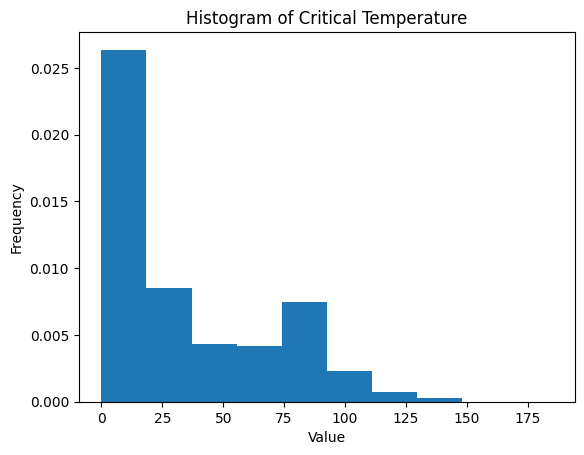

In [7]:
# Histogram of the target variable

plt.hist(x = y_train_full, # Daten
        # bins = ..., # Grenzen
        # range = ..., # Wertebereich
        density = True, # Normiert
        # color = ..., 
        # edgecolor = ...,
        # alpha = ..., # Durchsichtigkeit
        # label = "Histogram of critical Temperature"
        )
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Critical Temperature")
plt.show()

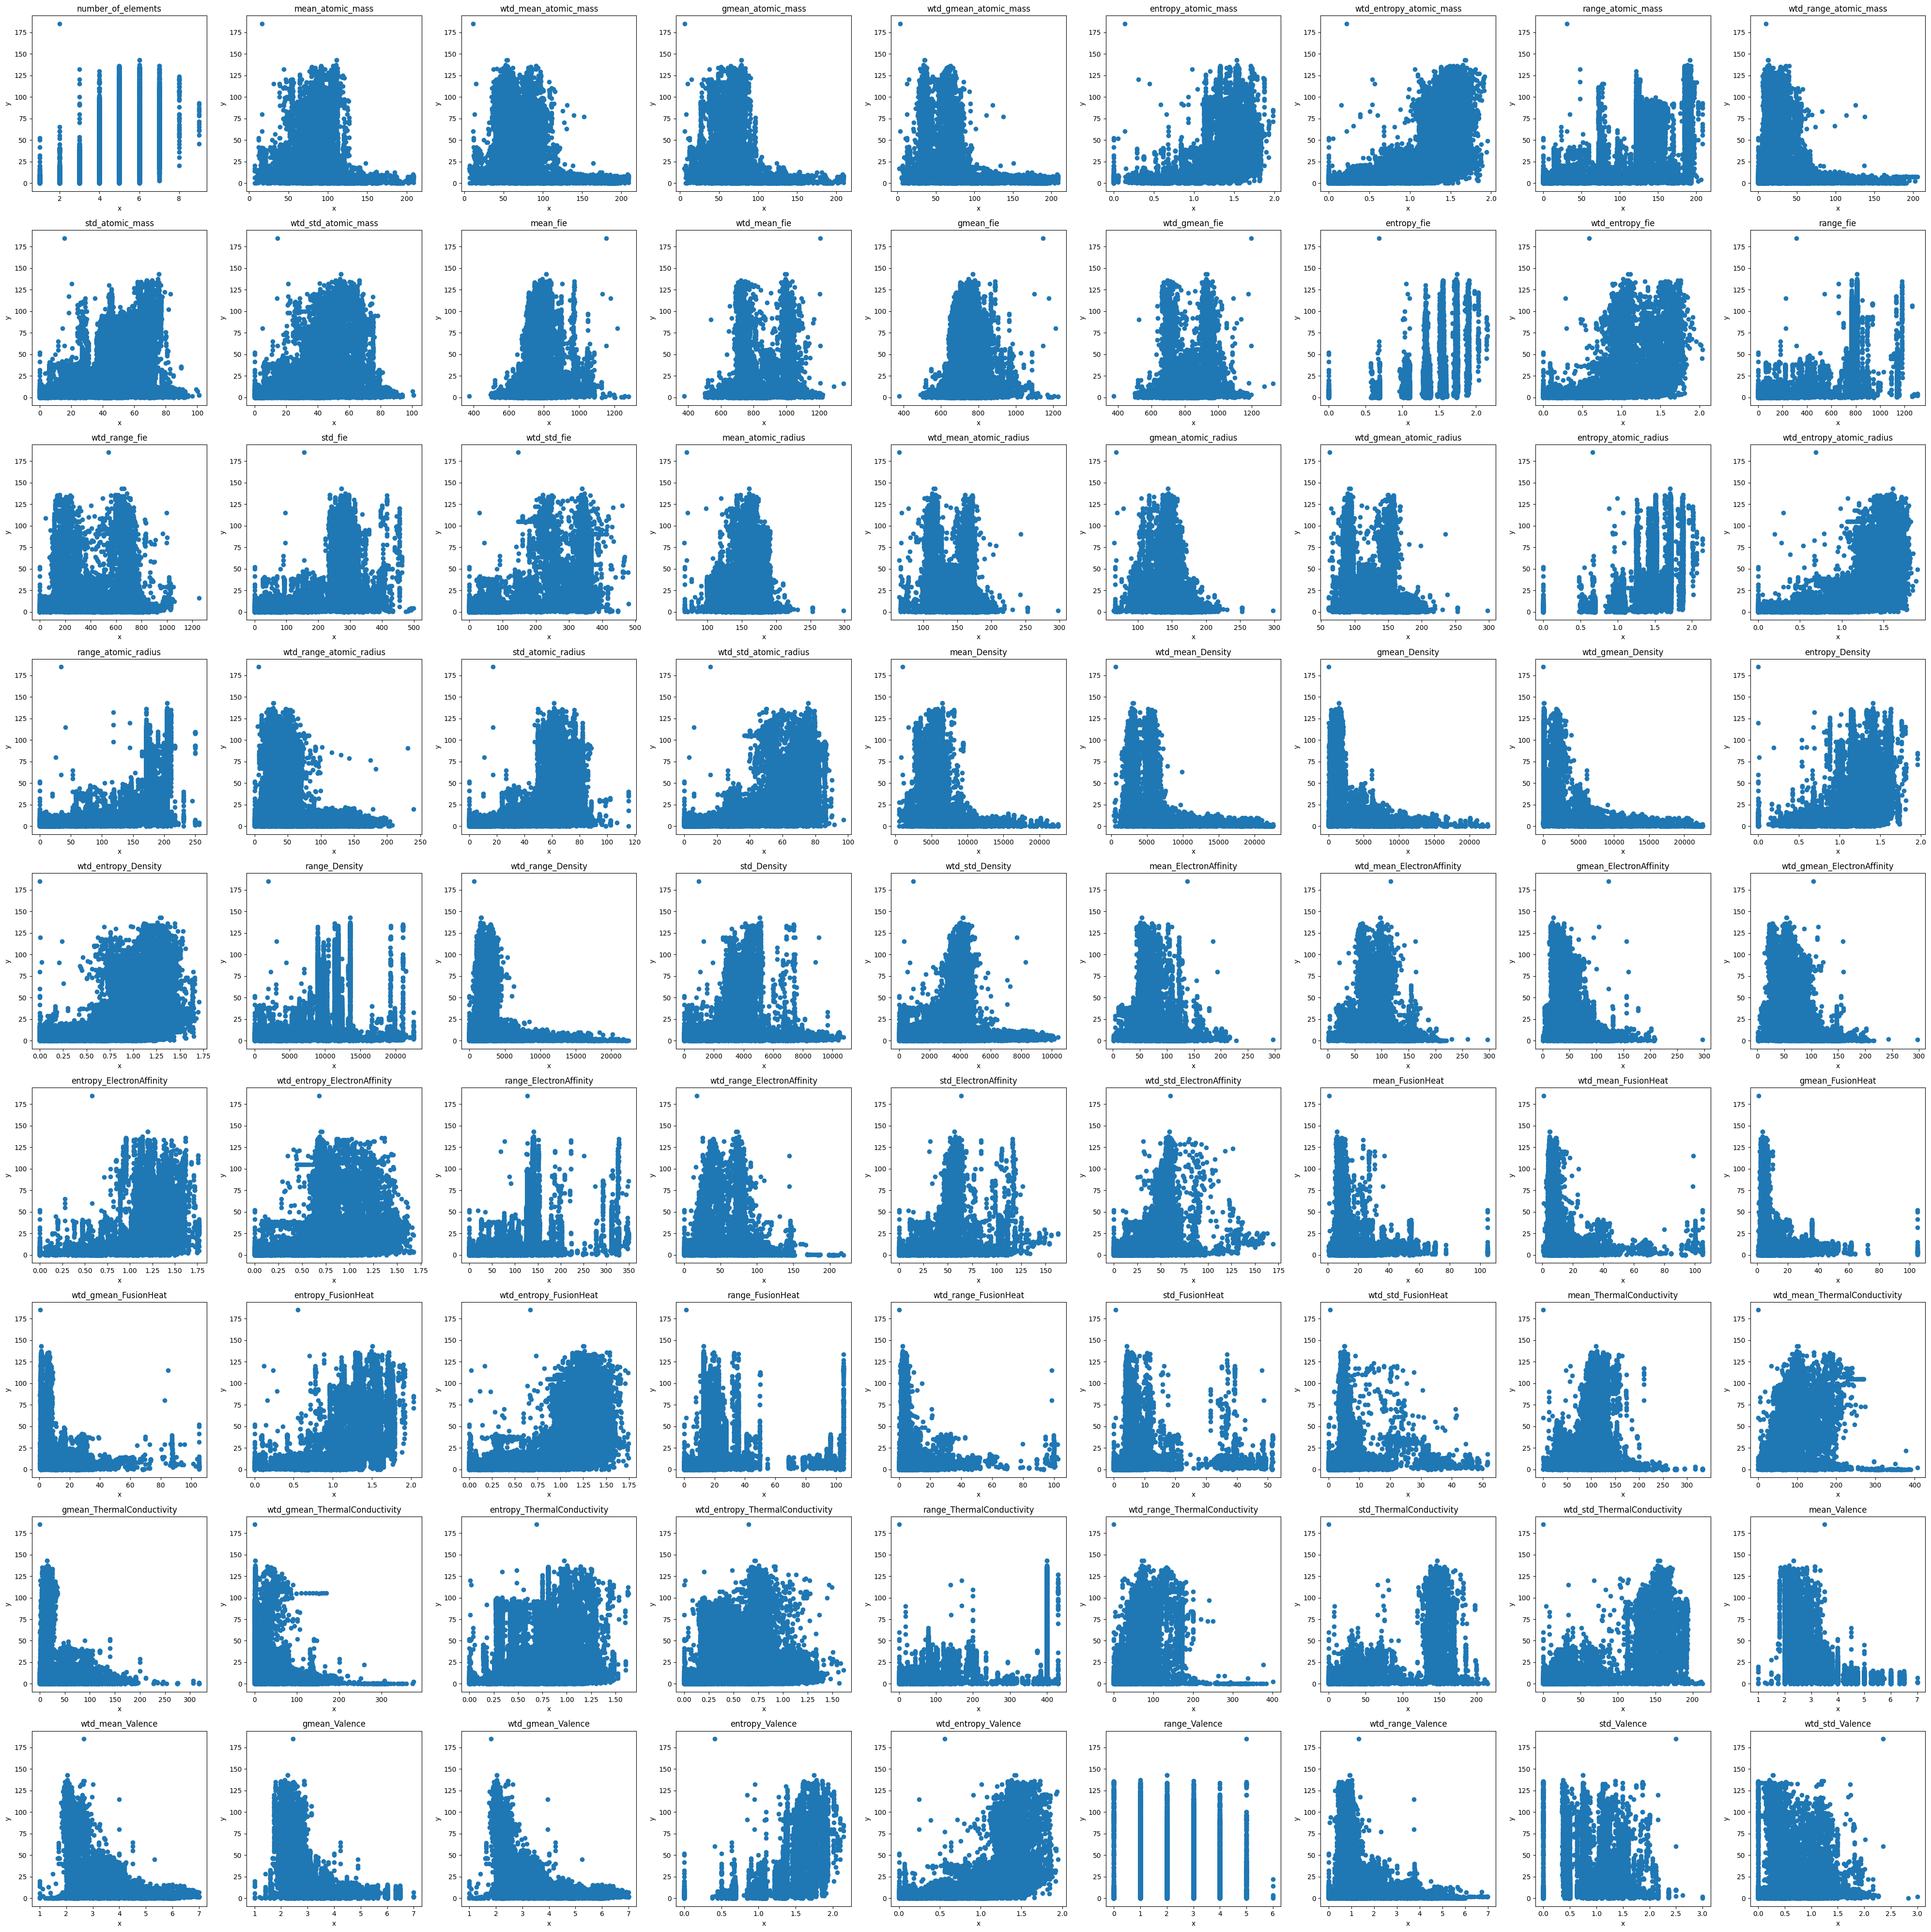

In [8]:
# Scatter plots of the target variable vs. features

fig, axes = plt.subplots(          # Erstellung von fig (Figure, Zeichenfläche) und axes (2D-Array mit subplotts) 
    9,                             # Anzahl der Zeilen in axes
    9,                             # Anzahl der Spalten in axes
    figsize = (40,40)              # Größe von fig (in Zoll)
)

for i, ax in enumerate(axes.flat):  
    ax.scatter(
        x = X_train_full_raw[:,i], # [Zeile,Spalte]; : für alle Zeilen 
        y = y_train_full,          # Datenpunkte
        # s = 50,                  # Größe der Punkte
        # c = ....,                # Farbe (oder Liste für Farbskala)
        # marker = ...,            # Form (z.B. 'x', '^', 's')
        # alpha = 0.7,             # Transparenz
        # cmap = None,             # Colormap bei Farbwerten
        # label = None
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    feature_name = feature_names[i]
    ax.set_title(f"{feature_name}") # correct: {feature_name} vs. {target_clm} but worse for readability

plt.tight_layout()
plt.savefig("scatter_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Normalize
def normalize_train_data(train_data):
    
    cols_norm_train = []                                              # Erzeugen einer list (einfacher und schneller ?!)
    
    for i in range(train_data.shape[1]):                              # for-Schleife über alle Spalten (response oder feature) in train_data
        col_train = train_data[:,i]                                   # Auswählen der i-ten Spalte von train_data
        
        mean_train = np.mean(col_train)                               # Berechnen des Mittelwerts der i-ten Spalte
        std_train = np.std(col_train)                                 # Berechnen der Standardabweichung der i-ten Spalte
        
        col_norm_train = (col_train - mean_train) / std_train         # Normalisierung der i-ten Spalte
        cols_norm_train.append(col_norm_train)                        # Hinzufügen der i-ten Spalte zur list
    
    train_data_normalized = np.column_stack(cols_norm_train)          # Umwandlung der List in einen array
    return(train_data_normalized)                                     # Ausgabe des arrays

In [10]:
X_train_normalized = normalize_train_data(X_train_raw)

summary = pd.DataFrame({
    "mean_before": np.mean(X_train_raw[:, :5], axis=0),
    "std_before": np.std(X_train_raw[:, :5], axis=0),
    "mean_after": np.mean(X_train_normalized[:, :5], axis=0),
    "std_after": np.std(X_train_normalized[:, :5], axis=0)
}, index=feature_names[:5])

summary.round(2)

,mean_before,std_before,mean_after,std_after
number_of_elements,4.18,1.51,0.0,1.0
mean_atomic_mass,87.72,29.24,-0.0,1.0
wtd_mean_atomic_mass,73.21,31.44,-0.0,1.0
gmean_atomic_mass,71.15,30.73,-0.0,1.0
wtd_gmean_atomic_mass,58.44,34.88,0.0,1.0


Which material properties may be useful for predicting superconductivity? What other observations can you make?

The relationships between the features and the target variable look noisy and not clearly linear in most, if not all, scatter plots. Some relationships appear to be nonlinear, possibly closer to exponential patterns rather than simple linear ones. Therefore, transformations such as applying a logarithm to some features could potentially improve the model performance, for example for `wtd_gmean_Density`. Many of the features are highly correlated. For example, for each material we include both the arithmetic and the geometric mean (`mean` vs. `gmean`). This could be problematic for a linear model.

The noisy relationships are probably due to the fact that the critical temperature of superconductors is determined by a combination of material properties. Looking at only one feature at a time therefore provides limited information.

## Task 2:  Implement your own OLS estimator

We want to use linear regression to predict the critical temperature. Implement the ordinary least squares estimator without regularization 'by hand':

$w = (X^TX)^{-1}X^Ty$

To make life a bit easier, we provide a function that can be used to plot regression results. In addition it computes the mean squared error and the squared correlation between the true and predicted values. 

In [11]:
def plot_regression_results(y_test, y_pred, weights):
    '''Produces three plots to analyze the results of linear regression:
        -True vs predicted
        -Raw residual histogram
        -Weight histogram

    Inputs:
        y_test: (n_observations,) numpy array with true values
        y_pred: (n_observations,) numpy array with predicted values
        weights: (n_weights) numpy array with regression weights'''

    print('MSE: ', mean_squared_error(y_test, y_pred))
    print('r^2: ', r2_score(y_test, y_pred))

    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    # predicted vs true
    ax[0].scatter(y_test, y_pred, s=2)
    ax[0].set_title('True vs. Predicted')
    ax[0].set_xlabel('True %s' % (target_clm))
    ax[0].set_ylabel('Predicted %s' % (target_clm))

    # residuals
    error = np.squeeze(np.array(y_test)) - np.squeeze(np.array(y_pred))
    ax[1].hist(np.array(error), bins=30)
    ax[1].set_title('Raw residuals')
    ax[1].set_xlabel('(true-predicted)')

    # weight histogram
    ax[2].hist(weights, bins=30)
    ax[2].set_title('weight histogram')

    plt.tight_layout()

As an example, we here show you how to use this function with random data. 

MSE:  17928.79570726673
r^2:  -13.313953173396845


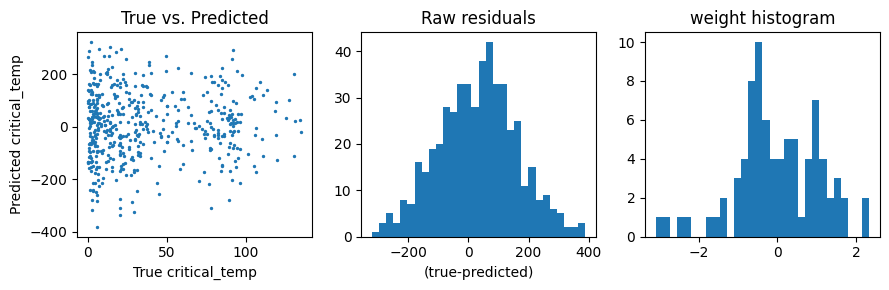

In [12]:
# weights is a vector of length 82: the first value is the intercept (beta0), then 81 coefficients
weights = np.random.randn(82)

# Model predictions on the test set
y_pred_testing = np.random.randn(y_test.size) * np.max(y_test)

plot_regression_results(y_test, y_pred_testing, weights)

Implement OLS linear regression yourself. Use `X_train` and `y_train` for estimating the weights and compute the MSE and $r^2$ from `X_test`. When you call our plotting function with the regression result, you should get mean squared error of 599.7.

In [13]:
def ols_regression(X_test, X_train, y_train):
    '''Computes OLS weights for linear regression without regularization on the training set and
       returns weights and testset predictions.

       Inputs:
         X_test: (n_observations, 81), numpy array with predictor values of the test set
         X_train: (n_observations, 81), numpy array with predictor values of the training set
         y_train: (n_observations,) numpy array with true target values for the training set

       Outputs:
         weights: The weight vector for the regerssion model including the offset
         y_pred: The predictions on the TEST set

       Note:
         Both the training and the test set need to be appended manually by a columns of 1s to add
         an offset term to the linear regression model.
    '''

    # ---------------- INSERT CODE ----------------------
    
    ones_test = np.ones(shape = (X_test.shape[0],1))
    ones_train = np.ones(shape = (X_train.shape[0],1))

    X_test = np.hstack(tup = (ones_test, X_test))
    X_train = np.hstack(tup = (ones_train, X_train))

    weights = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train 

    y_pred = X_test @ weights

    # ---------------- END CODE -------------------------

    return weights, y_pred

MSE:  599.7397624529365
r^2:  0.5211810644651367


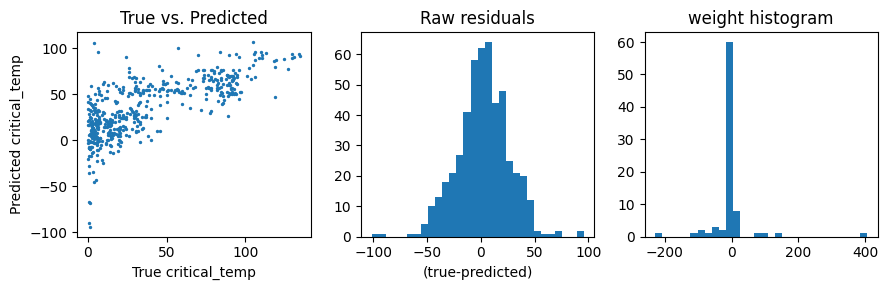

In [14]:
# Plots of the results
weights, y_pred = ols_regression(X_test_raw, X_train_raw, y_train)
plot_regression_results(y_test, y_pred, weights)

What do you observe? Is the linear regression model good?

With an `MSE` of about `599.7` and an `r^2` of `0.52`, roughly half of the variance is explained by the model. This means that the model has some predictive capability, but it is not extremely accurate. We cannot verify all assumptions of the linear model from the given plots, but the residuals seem to be roughly centered around zero and somewhat bell-shaped.

The weight histogram shows that many weights are close to zero. However, since the features are not necessarily on the same scale, the absolute size of the weights should be interpreted carefully. Overall, the results suggest that the linear model captures part of the relationship, but there is still substantial unexplained variation.

## Task 3: Compare your implementation to sklearn

Now, familiarize yourself with the sklearn library. In the section on linear models:

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model

you will find `sklearn.linear_model.LinearRegression`, the `sklearn` implementation of the OLS estimator. Use this sklearn class to implement OLS linear regression. Again obtain estimates of the weights on `X_train` and `y_train` and compute the MSE and $r^2$ on `X_test`.


In [15]:
def sklearn_regression(X_test, X_train, y_train):
    '''Computes OLS weights for linear regression without regularization using the sklearn library on the training set and
       returns weights and testset predictions.

       Inputs:
         X_test: (n_observations, 81), numpy array with predictor values of the test set
         X_train: (n_observations, 81), numpy array with predictor values of the training set
         y_train: (n_observations,) numpy array with true target values for the training set

       Outputs:
         weights: The weight vector for the regerssion model including the offset
         y_pred: The predictions on the TEST set

       Note:
         The sklearn library automatically takes care of adding a column for the offset.
    '''

    # ---------------- INSERT CODE ----------------------
    
    lm = linear_model.LinearRegression()
    lm.fit(X_train, y_train)
    weights = lm.coef_
    y_pred = lm.predict(X_test)

    # ---------------- END CODE -------------------------

    return weights, y_pred

MSE:  599.7397626189439
r^2:  0.5211810643326


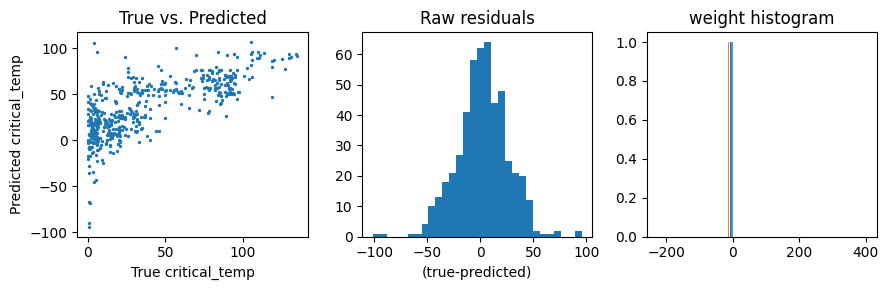

In [16]:
weights, y_pred = sklearn_regression(X_test_raw, X_train_raw, y_train)
plot_regression_results(y_test, y_pred, weights)

If you implemented everything correctly, the MSE is again 599.7.

Fit the model using the larger training set, `X_train_full` and `y_train_full`, and again evaluate on `X_test`.

MSE:  329.8607010413203
r^2:  0.7366465263176826


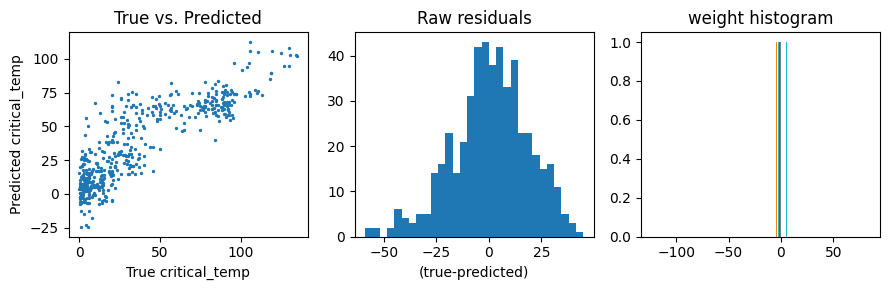

In [17]:
weights, y_pred = sklearn_regression(X_test_raw, X_train_full_raw, y_train_full)
plot_regression_results(y_test, y_pred, weights)

 How does test set performance change? What else changes?

When fitting the model on the larger training set, the test `MSE` decreases from `599.7` to `329.86`, and the test `r^2` increases from approximately `0.52` to `0.74`. Therefore, the predictive capability of the model improves substantially. The residuals are still centered around zero and have a roughly bell-shaped distribution. The weight histogram shows that the weights are now more concentrated around zero, suggesting that the larger training set leads to more stable weight estimates and reduces overfitting.

## Task 4: Regularization with ridge regression

We will now explore how a penalty term on the weights can improve the prediction quality for finite data sets. Implement the analytical solution of ridge regression 

$w = (X^TX + \alpha I_D)^{-1}X^Ty$


as a function that can take different values of $\alpha$, the regularization strength, as an input. In the lecture, this parameter was called $\lambda$, but this is a reserved keyword in Python.

In [18]:
def ridge_regression(X_test, X_train, y_train, alpha):
    '''Computes OLS weights for regularized linear regression with regularization strength alpha
       on the training set and returns weights and testset predictions.

       Inputs:
         X_test: (n_observations, 81), numpy array with predictor values of the test set
         X_train: (n_observations, 81), numpy array with predictor values of the training set
         y_train: (n_observations,) numpy array with true target values for the training set
         alpha: scalar, regularization strength

       Outputs:
         weights: The weight vector for the regression model including the offset
         y_pred: The predictions on the TEST set

       Note:
         Both the training and the test set need to be appended manually by a columns of 1s to add
         an offset term to the linear regression model.
    '''

    # ---------------- INSERT CODE ----------------------
    ones_test = np.ones(shape = (X_test.shape[0],1))
    ones_train = np.ones(shape = (X_train.shape[0],1))

    X_test = np.hstack(tup = (ones_test, X_test))
    X_train = np.hstack(tup = (ones_train, X_train))

    I = np.eye(N = X_train.shape[1])

    weights = np.linalg.inv(X_train.T @ X_train + alpha * I) @ X_train.T @ y_train

    y_pred = X_test @ weights

    # ---------------- END CODE -------------------------

    return weights, y_pred

Run the ridge regression on `X_train` with an alpha value of 10 and plot the obtained weights.

MSE:  429.7378500241927
r^2:  0.65690682394304


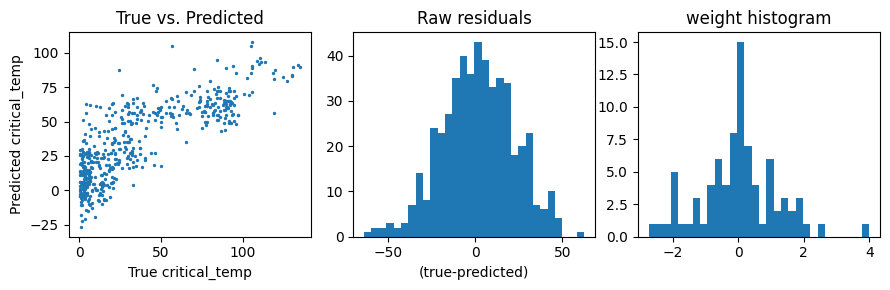

In [19]:
# Run ridge regression with alpha=10

alpha = 10
weights, y_pred = ridge_regression(X_test_raw, X_train_raw, y_train, alpha)

# Plot regression results

plot_regression_results(y_test, y_pred, weights)

Now test a range of log-spaced $\alpha\text{s}$ (~10-20), which cover several orders of magnitude, e.g. from 10^-7 to 10^7. 

* For each $\alpha$, you will get one model with one set of weights. 
* For each model, compute the error on the test set. 

Store both the errors and weights of all models for later use. You can use the function `mean_squared_error` from sklearn (imported above) to compute the MSE.


In [20]:
alphas = np.logspace(-7, 7, 20)

# ---------------- INSERT CODE ----------------------

rows = []
for alpha in alphas:
    weights, y_pred = ridge_regression(X_test_raw, X_train_raw, y_train, alpha)

    error = np.squeeze(np.array(y_test)) - np.squeeze(np.array(y_pred))
    MSE = mean_squared_error(y_test, y_pred)
    
    rows.append({"alpha": alpha, "weights": weights, "error": error, "MSE": MSE })

# ---------------- END CODE -------------------------

Make a single plot that shows for each coefficient how it changes with $\alpha$, i.e. one line per coefficient. Also think about which scale is appropriate for your $\alpha$-axis. You can set this using `plt.xscale(...)`.

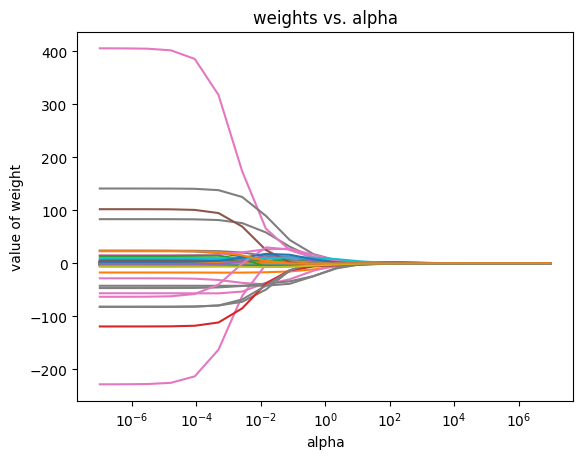

In [21]:
# Plot of coefficients vs. alphas
weights = np.array([row["weights"] for row in rows])
weights = weights.squeeze() # Um unnötige Dimension zu entfernen
for i in range(weights.shape[1]):
    x = alphas
    y = weights[:,i]
    plt.plot(x, y)
    
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("value of weight")
plt.title("weights vs. alpha")
plt.show()  

Why are the values of the weights largest on the left? Do they all change monotonically? 

With an $\alpha$ of zero, both linear regression and ridge regression yield the same results. That's the case on the left side of the plot, where $\alpha$ is almost zero and the weights are almost identical to OLS weights. As $\alpha$ increases, large coefficients (in absolute value) get more strongly penalized and pushed toward zero. Positive coefficients decrease monotonically as $\alpha$ increases, and negative coefficients increase monotonically toward zero.

Plot how the performance (i.e. the error) changes as a function of $\alpha$. As a sanity check, the MSE value for very small $\alpha$ should be close to the test-set MSE of the unregularized solution, i.e. 708.

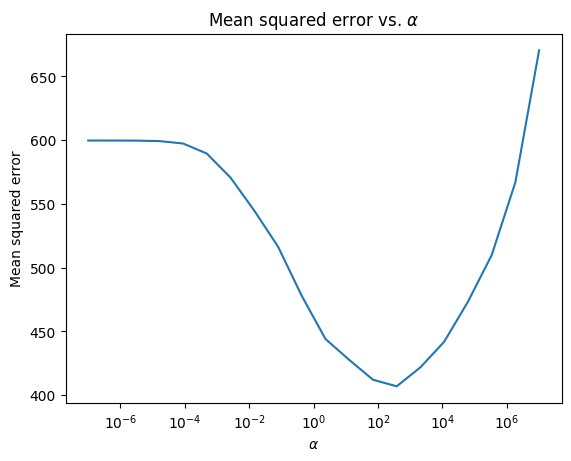

In [22]:
# Plot of MSE  vs. alphas
MSE = np.array([row["MSE"] for row in rows])
MSE.shape
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("Mean squared error")
plt.title(r"Mean squared error vs. $\alpha$")
plt.plot(alphas,MSE)

Which value of $\alpha$ gives the minimum MSE? Is it better than the unregularized model? Why should the curve reach ~700 on the left?

In [23]:
i = np.argmin([row["MSE"] for row in rows])
print(f'alpha: {rows[i]["alpha"]:.2f}, MSE: {rows[i]["MSE"]:.2f}')

alpha: 379.27, MSE: 406.93


From the tested values of $\alpha$, an $\alpha$ of `379.27` gives the lowest test MSE. The regularized Ridge regression performs considerably better on the test set than the unregularized linear regression, with a test MSE of `406.09` compared to `599.70`.

On the left side of the plot, $\alpha$ is close to zero. In this case, Ridge regression is almost identical to ordinary linear regression, since the penalty has almost no effect on the weight estimates. Therefore, the MSE approaches approximately the same value as the MSE of the unregularized linear model.

Now implement the same model using sklearn. Use the `linear_model.Ridge` object to do so.


In [24]:
def ridge_regression_sklearn(X_test, X_train, y_train, alpha):
    '''Computes OLS weights for regularized linear regression with regularization strength alpha using the sklearn
       library on the training set and returns weights and testset predictions.

       Inputs:
         X_test: (n_observations, 81), numpy array with predictor values of the test set
         X_train: (n_observations, 81), numpy array with predictor values of the training set
         y_train: (n_observations,) numpy array with true target values for the training set
         alpha: scalar, regularization strength

       Outputs:
         weights: The weight vector for the regerssion model including the offset
         y_pred: The predictions on the TEST set

       Note:
         The sklearn library automatically takes care of adding a column for the offset.
    '''

    # ---------------- INSERT CODE ----------------------
    ridge = linear_model.Ridge(alpha = alpha)
    ridge.fit(X_train, y_train)
    weights = ridge.coef_
    y_pred = ridge.predict(X_test)
    # ---------------- END CODE -------------------------

    return weights, y_pred

This time, only plot how the performance changes as a function of $\alpha$. 

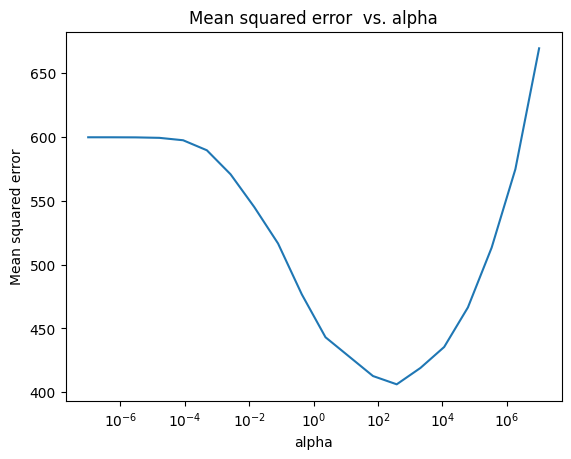

In [25]:
# Plot of MSE  vs. alphas
rows = []
for alpha in alphas:
    weights, y_pred = ridge_regression_sklearn(X_test_raw, X_train_raw, y_train, alpha)
    MSE = mean_squared_error(y_test, y_pred)
    
    rows.append({"alpha": alpha, "MSE": MSE })

MSE = np.array([row["MSE"] for row in rows])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Mean squared error")
plt.title("Mean squared error  vs. alpha")
plt.plot(alphas,MSE)

Note: Don't worry if the curve is not exactly identical to the one you got above. The loss function we wrote down in the lecture  has $\alpha$ defined a bit differently compared to sklearn. However, qualitatively it should look the same.

## Task 5: Cross-validation

Until now, we always estimated the error on the test set directly. However, we typically do not want to tune hyperparameters of our inference algorithms like $\alpha$ on the test set, as this may lead to overfitting. Therefore, we tune them on the training set using cross-validation. As discussed in the lecture, the training data is here split in `n_folds`-ways, where each of the folds serves as a held-out dataset in turn and the model is always trained on the remaining data. Implement a function that performs cross-validation for the ridge regression parameter $\alpha$. You can reuse functions written above.

In [26]:
def ridgeCV(X, y, n_folds, alphas):
    '''Runs a n_fold-crossvalidation over the ridge regression parameter alpha.
       The function should train the linear regression model for each fold on all values of alpha.

      Inputs:
        X: (n_obs, n_features) numpy array - predictor
        y: (n_obs,) numpy array - target
        n_folds: integer - number of CV folds
        alphas: (n_parameters,) - regularization strength parameters to CV over

      Outputs:
        cv_results_mse: (n_folds, len(alphas)) numpy array, MSE for each cross-validation fold

      Note:
        Fix the seed for reproducibility.
    '''

    cv_results_mse = np.zeros((n_folds, len(alphas)))
    np.random.seed(seed=2)

    # ---------------- INSERT CODE ----------------------
    
    idx = np.arange(X.shape[0])                # oder y.shape[0]
    idx_shuffled = np.random.permutation(idx)  # shuffle index randomly

    folds = np.array_split(idx_shuffled, n_folds) # Erstellen von list mit n_folds (AnzahL) arrays die indizes von Beobachtungen in im validation set enthalten. Dabei können die vorderen folds 1 größer sein, falls die Daten nicht genau durch n_folds teilbar sind (im Unterschied zu np.split [benötigt exakte Teilbarkeit]) 
    for i in range(n_folds):
        for j, alpha in enumerate(alphas):
            
            val_idx = folds[i]
            train_idx = np.concatenate([folds[j] for j in range(n_folds) if j != i], axis = 0) # <=> entlang der ersten Axe (axis = 0) [also Zeilen] erweitern. Äquivalent zu hstack 
            
            X_val = X[val_idx] # <=> X_train = X[train_idx, :] => Wenn nur ein Indexargument angegeben wird bezieht es sich auf die erste Achse (Zeilen)
            y_val = y[val_idx]
    
            X_train = X[train_idx]
            y_train = y[train_idx]

            weights, y_pred = ridge_regression(X_val, X_train, y_train, alpha)
            
            mse = mean_squared_error(y_val, y_pred)

            cv_results_mse[i, j] = mse 
    
    # ---------------- END CODE -------------------------

    return cv_results_mse

Now we run 10-fold cross-validation using the training data of a range of $\alpha$s.

In [27]:
alphas = np.logspace(-7, 7, 100)
mse_cv = ridgeCV(X_train_raw, y_train, n_folds=10, alphas=alphas)

We plot the MSE trace for each fold separately:

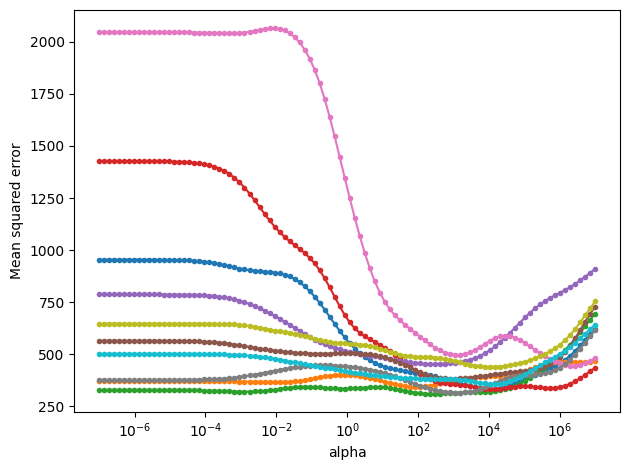

In [28]:
plt.plot(alphas, mse_cv.T, '.-')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean squared error')
plt.tight_layout()

We also plot the average across folds:

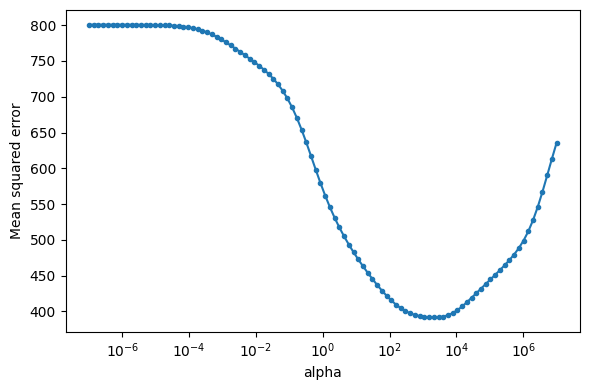

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(alphas, np.mean(mse_cv, axis=0), '.-')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean squared error')
plt.tight_layout()

What is the optimal $\alpha$? Is it similar to the one found on the test set? Do the cross-validation MSE and the test-set MSE match well or differ strongly?

In [30]:
rows = []

for alpha, mse in zip(alphas, np.mean(mse_cv, axis=0)):
    rows.append({
        "alpha": alpha,
        "MSE": mse
    })

i = np.argmin([row["MSE"] for row in rows])
print(f'alpha: {rows[i]["alpha"]:.2f}, MSE: {rows[i]["MSE"]:.2f}')

alpha: 2104.90, MSE: 391.62


With cross-validation, the optimal $\alpha$ is `2104.90`, which is considerably higher than the value of `379.27` found without cross-validation by evaluating directly on the test set. The average cross-validation MSE is `391.62`, while the minimum test-set MSE found before was `406.09`.

Although the optimal $\alpha$ values differ, both approaches show that Ridge regularization improves the model compared to the unregularized linear regression. The cross-validation MSE and the test-set MSE are also relatively similar, so they do not differ strongly.

We will now run cross-validation on the full training data. This will take a moment, depending on the speed of your computer. Afterwards, we will again plot the mean CV curves for the full data set (blue) and the small data set (orange).

In [31]:
alphas = np.logspace(-7, 7, 100)
mse_cv_full = ridgeCV(X_train_full_raw, y_train_full, n_folds=10, alphas=alphas)

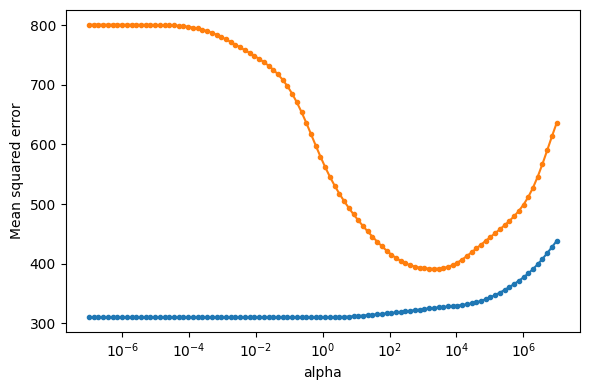

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(alphas, np.mean(mse_cv_full, axis=0), '.-')
plt.plot(alphas, np.mean(mse_cv, axis=0), '.-')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean squared error')
plt.tight_layout()

We zoom in on the blue curve to the very left:

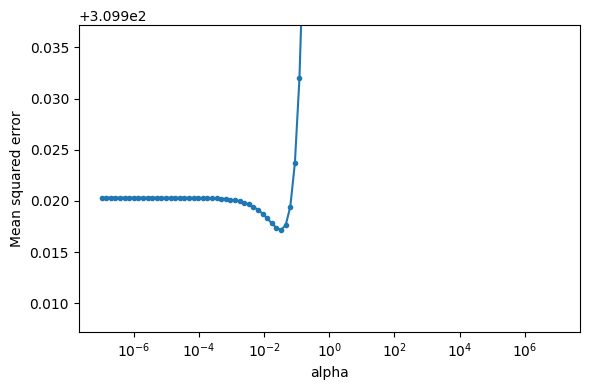

In [33]:
plt.figure(figsize=(6, 4))
plt.plot(alphas, np.mean(mse_cv_full, axis=0), '.-')
plt.xscale('log')
minValue = np.min(np.mean(mse_cv_full, axis=0))
plt.ylim([minValue-.01, minValue+.02])
plt.xlabel('alpha')
plt.ylabel('Mean squared error')
plt.tight_layout()

Why does the CV curve on the full data set look so different? What is the optimal value of $\alpha$ and why is it so much smaller than on the small training set?

In [34]:
rows = []

for alpha, mse in zip(alphas, np.mean(mse_cv_full, axis=0)):
    rows.append({
        "alpha": alpha,
        "MSE": mse
    })

i = np.argmin([row["MSE"] for row in rows])
print(f'alpha: {rows[i]["alpha"]:.2f}, MSE: {rows[i]["MSE"]:.2f}')

alpha: 0.03, MSE: 309.92


With more data, overfitting is reduced and the model needs less regularization. Therefore, the optimal $\alpha$ is much smaller, with a value of `0.03`, while cross-validation on the small training set required an $\alpha$ of `2104.90` to minimize the average MSE. The average MSE for the optimal $\alpha$ is also considerably smaller, with a value of `309.92`, compared to `391.62` on the smaller training set.